# 각 센서 단독 nowcast 베이스라인 (persistence 대비)

> 2026-06-19 · 상관분석(도로↔하수 결합 약함) 다음 단계 · **cross-센서 엣지 없이 각 센서 자기이력만** 사용

**설정**
- 데이터: `road_panel_10min`(준비된 split/label). 해상도 10분, **호라이즌 H=+10/+30/+60분(=1/3/6 스텝)**.
- 피처: **자기이력만**(road_max·level_diff·dur·stuck_frac·lag1/3/6·rolling3/6·hour·month·grade) — 다른 센서 입력 없음.
- 베이스라인: **persistence**(회귀 ŷ=현재 수위, 분류 ŷ=현재 침수상태). 모델: HistGradientBoosting.
- split: train 학습 / test 평가(시간순). 타겟은 갭 인지(10·H분 정확히 떨어질 때만).

**정직한 지표** (라벨 희소·0지배·오염 때문):
- 회귀: 전체 MAE는 0지배라 무의미 → **event-조건부 MAE**(현재 활성)·**skill=1−MAE_model/MAE_pers**.
- 분류: flood_t6 양성률 0.33% → 정확도 무의미 → **PR-AUC**, persistence와 비교. ⚠️ flood_t6은 stuck 오염 잔존.


In [1]:
import pandas as pd, numpy as np, time
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, average_precision_score, precision_score, recall_score, precision_recall_curve
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
OUT=Path("dataset/processed/eda_based"); FIG=Path("reports/figures_baseline"); FIG.mkdir(parents=True,exist_ok=True)
korf=next((c for c in ['NanumGothic','Malgun Gothic','AppleGothic','Noto Sans CJK KR','UnDotum'] if c in {f.name for f in fm.fontManager.ttflist}),None)
if korf: plt.rcParams['font.family']=korf
plt.rcParams['axes.unicode_minus']=False

cols=['sensor_id','ts10','road_max','road_mean','level_diff','n_valid','stuck_frac','dur_ge2','dur_ge6','dur_ge10','split','month','flood_t6','flood_t6_sus','grade']
df=pd.read_parquet(OUT/"road_panel_10min.parquet",columns=cols).sort_values(['sensor_id','ts10']).reset_index(drop=True)
g=df.groupby('sensor_id',sort=False)
for L in (1,3,6): df[f'rmax_l{L}']=g['road_max'].shift(L)
df['rmax_roll3']=g['road_max'].transform(lambda s:s.rolling(3,min_periods=1).mean())
df['rmax_roll6']=g['road_max'].transform(lambda s:s.rolling(6,min_periods=1).mean())
df['hour']=df['ts10'].dt.hour; df['grade_n']=df['grade'].map({'A':0,'B':1,'C':2}).fillna(1)
FEAT=['road_max','road_mean','level_diff','n_valid','stuck_frac','dur_ge2','dur_ge6','dur_ge10','rmax_l1','rmax_l3','rmax_l6','rmax_roll3','rmax_roll6','hour','month','grade_n']
def masks(H):
    valid=((g['ts10'].shift(-H)-df['ts10']).dt.total_seconds()/60==10*H)
    tr=valid&(df.split=='train')&df['road_max'].notna()
    te=valid&(df.split=='test') &df['road_max'].notna()
    return valid,tr,te
print("준비 완료:",len(df),"행")


준비 완료: 5690975 행


## A. 수위 회귀 — road_max(t+H), persistence vs HGB

 H  MAE_pers  MAE_model  skill  MAE_pers_ev  MAE_model_ev  skill_ev
10    0.0077     0.0115 -0.488        0.072         0.079    -0.093
30    0.0124     0.0189 -0.530        0.109         0.118    -0.087
60    0.0165     0.0244 -0.481        0.141         0.140     0.007
→ skill>0 이면 persistence 능가. 음수면 모델이 더 나쁨.


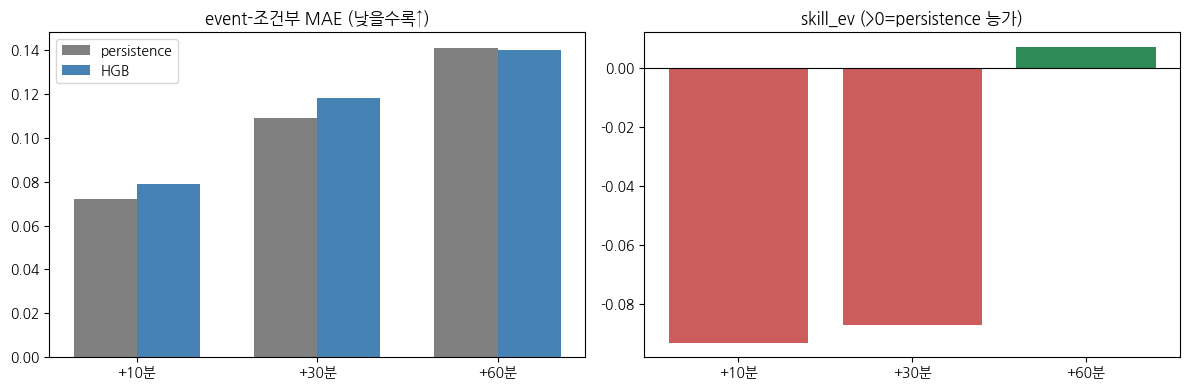

In [2]:
rowsR=[]; ex=None
for H in (1,3,6):
    valid,tr,te=masks(H)
    yreg=g['road_max'].shift(-H)
    tr=tr&yreg.notna(); te=te&yreg.notna()
    reg=HistGradientBoostingRegressor(max_iter=120,learning_rate=0.1,max_depth=6).fit(df.loc[tr,FEAT],yreg[tr].values)
    pr=reg.predict(df.loc[te,FEAT]); pers=df.loc[te,'road_max'].values; y=yreg[te].values
    act=pers>0
    mae_p=mean_absolute_error(y,pers); mae_m=mean_absolute_error(y,pr)
    mae_pe=mean_absolute_error(y[act],pers[act]); mae_me=mean_absolute_error(y[act],pr[act])
    rowsR.append(dict(H=H*10,MAE_pers=round(mae_p,4),MAE_model=round(mae_m,4),skill=round(1-mae_m/mae_p,3),
                      MAE_pers_ev=round(mae_pe,3),MAE_model_ev=round(mae_me,3),skill_ev=round(1-mae_me/mae_pe,3)))
    if H==1: ex=(y[act],pers[act],pr[act])
Rreg=pd.DataFrame(rowsR); print(Rreg.to_string(index=False))
print("→ skill>0 이면 persistence 능가. 음수면 모델이 더 나쁨.")
fig,ax=plt.subplots(1,2,figsize=(12,4))
x=np.arange(len(Rreg)); w=.35
ax[0].bar(x-w/2,Rreg.MAE_pers_ev,w,label='persistence',color='gray'); ax[0].bar(x+w/2,Rreg.MAE_model_ev,w,label='HGB',color='steelblue')
ax[0].set_xticks(x); ax[0].set_xticklabels([f'+{h}분' for h in Rreg.H]); ax[0].set_title('event-조건부 MAE (낮을수록↑)'); ax[0].legend()
ax[1].bar(x,Rreg.skill_ev,color=['seagreen' if s>0 else 'indianred' for s in Rreg.skill_ev]); ax[1].axhline(0,color='k',lw=.8)
ax[1].set_xticks(x); ax[1].set_xticklabels([f'+{h}분' for h in Rreg.H]); ax[1].set_title('skill_ev (>0=persistence 능가)')
plt.tight_layout(); plt.savefig(FIG/'01_regression.png',dpi=110); plt.show()


## B. 침수 분류 — flood_t6(t+H), persistence vs HGB

⚠️ flood_t6은 stuck/겨울 오염 잔존 → 높은 점수가 '진짜 침수 예측력'은 아님(persistence 점수 자체가 오염 지표).

 H  pos  base_rate  PRAUC_pers  PRAUC_model  pers_prec  pers_rec
10 3316     0.0033       0.847        0.938      0.915     0.926
30 3280     0.0032       0.791        0.903      0.883     0.896
60 3246     0.0032       0.750        0.873      0.858     0.873


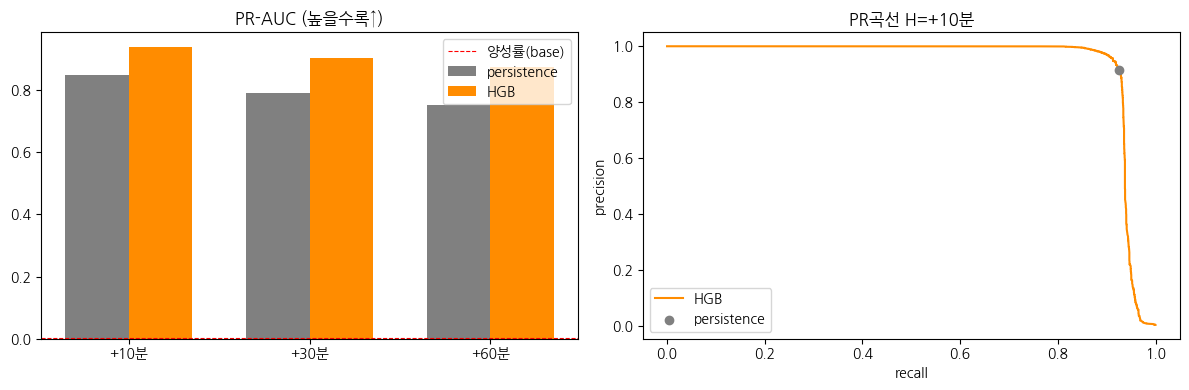

In [3]:
rowsC=[]; pr1=None
for H in (1,3,6):
    valid,tr,te=masks(H)
    yclf=g['flood_t6'].shift(-H)
    tr=tr&yclf.notna(); te=te&yclf.notna()
    clf=HistGradientBoostingClassifier(max_iter=150,learning_rate=0.1,max_depth=6,class_weight='balanced').fit(df.loc[tr,FEAT],yclf[tr].astype(int).values)
    proba=clf.predict_proba(df.loc[te,FEAT])[:,1]; y=yclf[te].astype(int).values; persc=df.loc[te,'flood_t6'].astype(int).values
    rowsC.append(dict(H=H*10,pos=int(y.sum()),base_rate=round(y.mean(),4),
        PRAUC_pers=round(average_precision_score(y,persc),3),PRAUC_model=round(average_precision_score(y,proba),3),
        pers_prec=round(precision_score(y,persc,zero_division=0),3),pers_rec=round(recall_score(y,persc,zero_division=0),3)))
    if H==1: pr1=(y,proba,persc)
Rclf=pd.DataFrame(rowsC); print(Rclf.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(12,4))
x=np.arange(len(Rclf)); w=.35
ax[0].bar(x-w/2,Rclf.PRAUC_pers,w,label='persistence',color='gray'); ax[0].bar(x+w/2,Rclf.PRAUC_model,w,label='HGB',color='darkorange')
ax[0].axhline(Rclf.base_rate.mean(),color='r',ls='--',lw=.8,label='양성률(base)'); ax[0].set_xticks(x); ax[0].set_xticklabels([f'+{h}분' for h in Rclf.H])
ax[0].set_title('PR-AUC (높을수록↑)'); ax[0].legend()
y,proba,persc=pr1; p,r,_=precision_recall_curve(y,proba)
ax[1].plot(r,p,color='darkorange',label='HGB'); ax[1].scatter([recall_score(y,persc)],[precision_score(y,persc)],color='gray',zorder=5,label='persistence')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('PR곡선 H=+10분'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'02_classification.png',dpi=110); plt.show()
pd.concat([Rreg.assign(task='reg'),Rclf.assign(task='clf')],ignore_index=True).to_parquet(OUT/'baseline_metrics.parquet')


## C. 정제 라벨에서 재측정 — 오염 거품 정량화

flood_t6은 stuck 센서·단발 노이즈로 오염돼 있다(test 양성 3380개 중 **stuck bin이 56%**). 정제할수록 점수가 얼마나 떨어지는지로 **오염 거품**을 잰다.
- `flood_t6` 전체(현행) → `flood_t6` **stuck 제거**(`stuck_frac==0`) → `flood_t6_sus`(지속) **stuck 제거**(최정제).
- 정제 시 persistence PR-AUC 하락분 = 'stuck이 trivially 지속돼 부풀린 거품'.


In [ ]:
def expC(label,H,drop_stuck):
    valid=((g['ts10'].shift(-H)-df['ts10']).dt.total_seconds()/60==10*H)
    y=g[label].shift(-H); keep=valid&df['road_max'].notna()&y.notna()
    if drop_stuck: keep=keep&(df['stuck_frac']==0)
    tr=keep&(df.split=='train'); te=keep&(df.split=='test')
    clf=HistGradientBoostingClassifier(max_iter=150,learning_rate=0.1,max_depth=6,class_weight='balanced').fit(df.loc[tr,FEAT],y[tr].astype(int).values)
    proba=clf.predict_proba(df.loc[te,FEAT])[:,1]; yt=y[te].astype(int).values; persc=df.loc[te,'flood_t6'].astype(int).values
    return dict(라벨=label,필터=('stuck제거' if drop_stuck else '전체(현행)'),H=H*10,양성=int(yt.sum()),
        PRAUC_pers=round(average_precision_score(yt,persc),3),PRAUC_model=round(average_precision_score(yt,proba),3))
rowsCl=[]
for H in (1,3):
    rowsCl+=[expC('flood_t6',H,False),expC('flood_t6',H,True),expC('flood_t6_sus',H,True)]
Rcl=pd.DataFrame(rowsCl); print(Rcl.to_string(index=False))
print("\n→ persistence PR-AUC 하락분이 stuck 오염 거품. H=+10분 0.847→0.678(-0.17).")
sub=Rcl[Rcl.H==10]; lbl=['flood_t6\n전체(오염)','flood_t6\nstuck제거','flood_t6_sus\nstuck제거']
x=np.arange(3); w=.35; fig,ax=plt.subplots(figsize=(8,4.2))
ax.bar(x-w/2,sub.PRAUC_pers,w,label='persistence',color='gray'); ax.bar(x+w/2,sub.PRAUC_model,w,label='HGB',color='darkorange')
for i,(p,m) in enumerate(zip(sub.PRAUC_pers,sub.PRAUC_model)): ax.text(i-w/2,p+.01,p,ha='center',fontsize=8); ax.text(i+w/2,m+.01,m,ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(lbl); ax.set_ylim(0,1); ax.set_title('정제수준별 PR-AUC (H=+10분) — 정제 시 하락분=오염 거품'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'03_cleaned_labels.png',dpi=110); plt.show()
Rcl.to_parquet(OUT/'baseline_cleaned_clf.parquet')


## 결론

- **수위 회귀: persistence를 못 이긴다.** 자기이력 HGB skill_ev가 +10/+30분 음수, +60분 +0.03 → naive-last가 사실상 최강(road_max 0/지속 지배).
- **침수 분류(현행 flood_t6): 모델 PR-AUC 0.94 vs persistence 0.85(@+10분)** — 그러나 둘 다 **오염으로 부풀려짐**.
- **오염 거품 정량화(§C)**: stuck 제거 시 persistence PR-AUC **0.847→0.678(@+10분, -0.17≈20%)**, +30분은 0.791→0.570로 더 큼. 모델도 0.938→0.841로 하락. **현행 점수의 ~20%는 stuck이 trivially 지속돼 만든 거품.**
  - 단 최정제 라벨(`flood_t6_sus`+stuck제거)에선 모델 0.909 vs persistence 0.695로 **모델 우위가 오히려 커짐** → 지속 침수엔 단기 예측 여지가 일부 있을 수 있음(단 강우 미검증·소수 센서 집중이라 잠정).

**종합** — ① 단독 nowcast에서 **persistence가 강한 바**, 수위 회귀는 못 이김. ② 침수 분류의 높은 점수는 **상당 부분(~20%+) stuck 오염 거품**이고, 정제하면 과제가 더 어려워짐(특히 긴 H). ③ 정제 라벨에선 모델이 persistence 대비 여지를 보이나 잠정. → **진짜 개선은 라벨 정제 + 강우 확보**에서 온다는 결론 재확인.

**다음** — (강우 확보 시) 강우동반 라벨 정제·강우 피처 추가 후 재평가 / 양성 집중 소수 센서의 진위(진짜 상습침수 vs 잔여 아티팩트) 개별 검토.
